# 📈 Multi-Series Retail Demand Optimization - Advanced EDA
**Author:** Aman sain  
**Dataset Source:** `training.csv` strictly for Training Domain.  

---

### 🚀 Step 1: Environment Setup & Data Loading

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Data Load Section
file_path = r'C:\Users\LENOVO\Multi_Series_Forecasting_for_Retail_Demand_Optimization\data\raw\training.csv'
df = pd.read_csv(file_path)

# Enforcing standard datetime format conversion (Strict baseline constraint)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['store', 'item', 'date']).reset_index(drop=True)

print(f" Dataset successfully ingested! Shape: {df.shape[0]} rows, {df.shape[1]} columns")

 Dataset successfully ingested! Shape: 913000 rows, 4 columns


1. Dataset Overview

In [15]:
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

Dataset Shape
(913000, 4)

Columns
['date', 'store', 'item', 'sales']

Data Types
date     datetime64[us]
store             int64
item              int64
sales             int64
dtype: object


2. First & Last Records

In [16]:
print(df.head())

print(df.tail())

        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14
3 2013-01-04      1     1     13
4 2013-01-05      1     1     10
             date  store  item  sales
912995 2017-12-27     10    50     63
912996 2017-12-28     10    50     59
912997 2017-12-29     10    50     74
912998 2017-12-30     10    50     62
912999 2017-12-31     10    50     82


3. Missing Values

In [17]:
print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())

Missing Values
date     0
store    0
item     0
sales    0
dtype: int64


4. Duplicate Records

In [18]:
print("="*60)
print("Duplicate Records")
print("="*60)

print(df.duplicated().sum())

Duplicate Records


0


5. Statistical Summary

In [19]:
print("="*60)
print("Statistical Summary")
print("="*60)

print(df.describe())

Statistical Summary
                      date          store           item          sales
count               913000  913000.000000  913000.000000  913000.000000
mean   2015-07-02 12:00:00       5.500000      25.500000      52.250287
min    2013-01-01 00:00:00       1.000000       1.000000       0.000000
25%    2014-04-02 00:00:00       3.000000      13.000000      30.000000
50%    2015-07-02 12:00:00       5.500000      25.500000      47.000000
75%    2016-10-01 00:00:00       8.000000      38.000000      70.000000
max    2017-12-31 00:00:00      10.000000      50.000000     231.000000
std                    NaN       2.872283      14.430878      28.801144


6. Sales Distribution

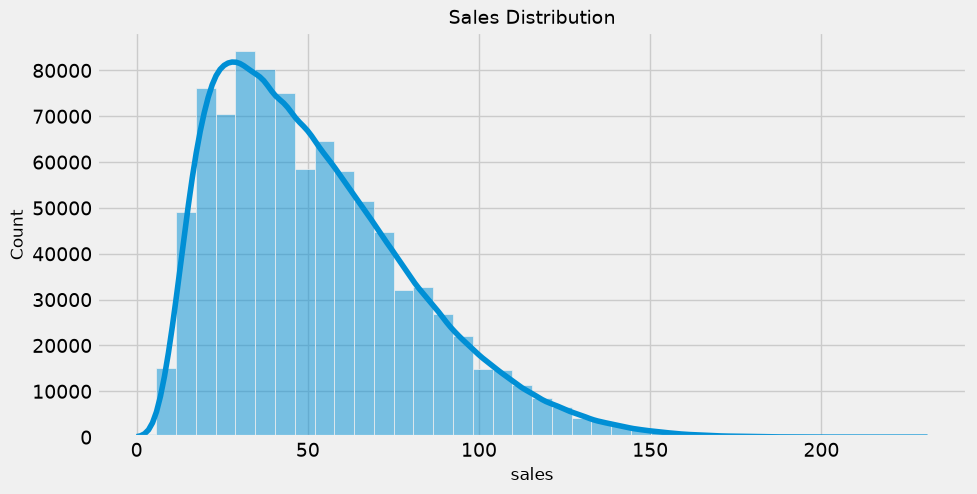

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df['sales'],bins=40,kde=True)

plt.title("Sales Distribution")

plt.show()

7. Monthly Sales Trend

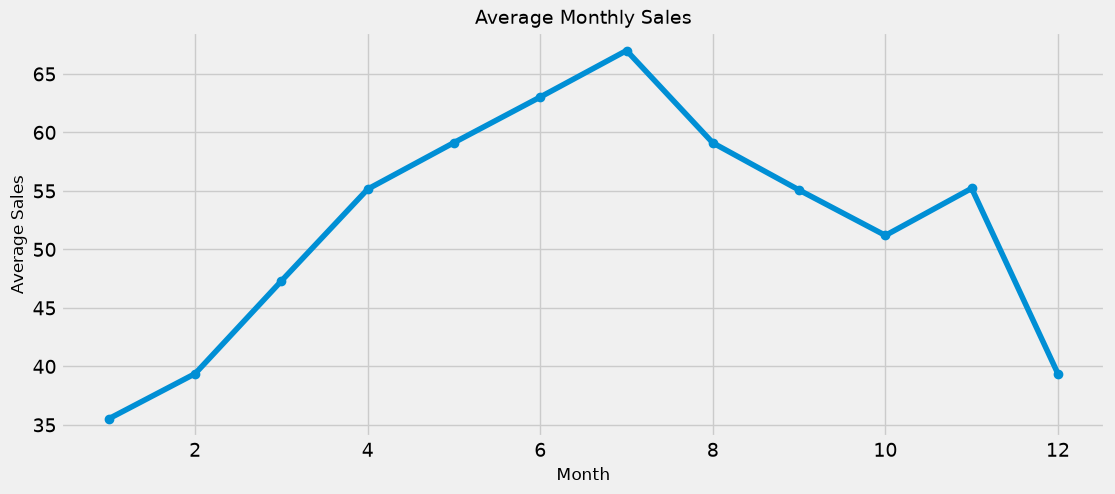

In [21]:
monthly_sales=df.groupby(df['date'].dt.month)['sales'].mean()

plt.figure(figsize=(12,5))

monthly_sales.plot(marker='o')

plt.title("Average Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Average Sales")

plt.grid(True)

plt.show()

8. Store-wise Sales

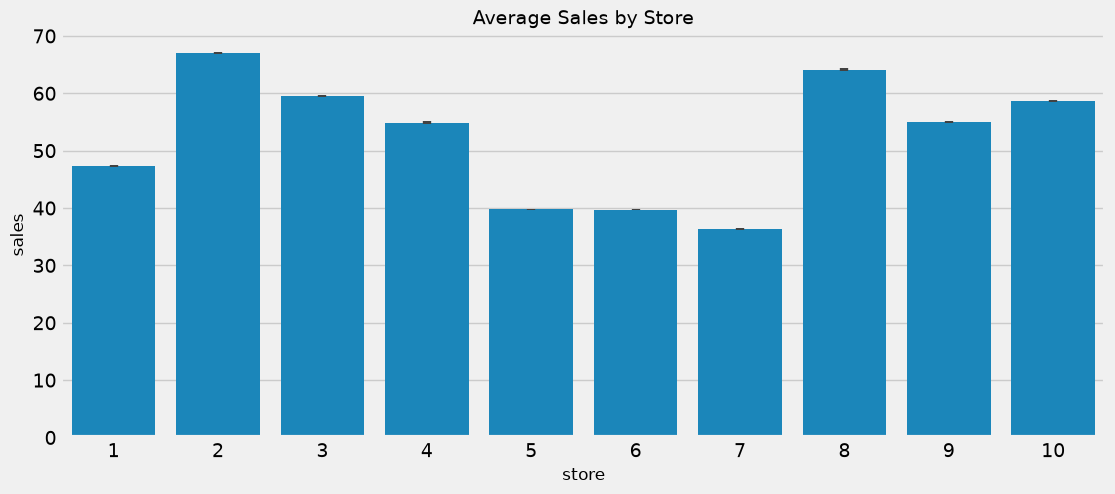

In [22]:
plt.figure(figsize=(12,5))

sns.barplot(data=df,x='store',y='sales',estimator=np.mean)

plt.title("Average Sales by Store")

plt.show()

9. Item-wise Top Selling Products

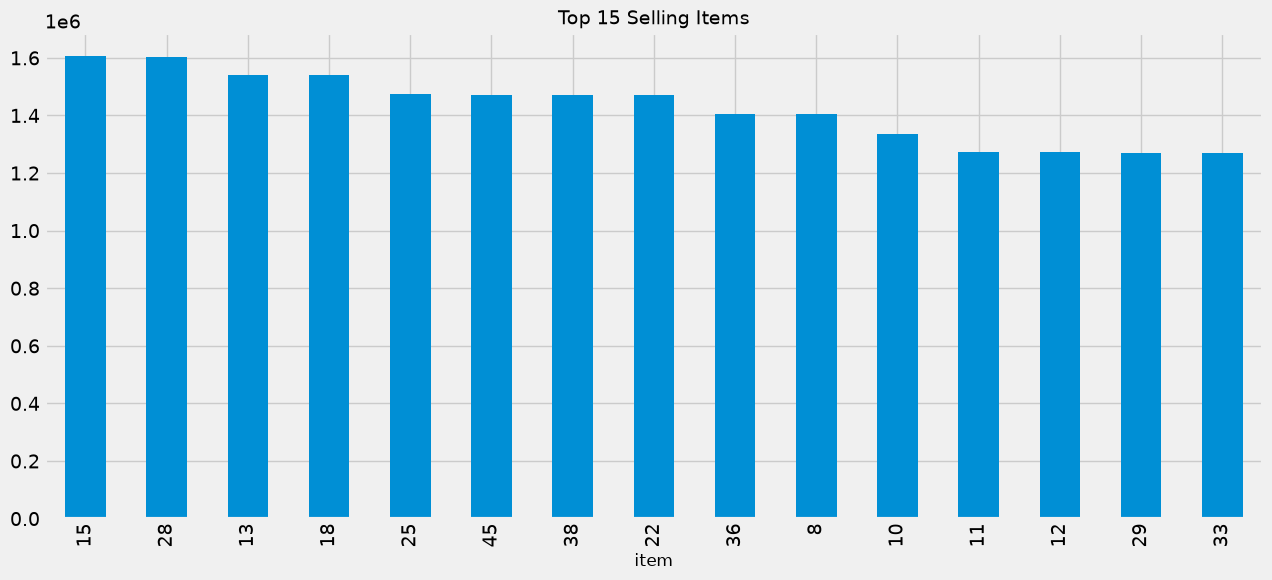

In [23]:
top_items=df.groupby('item')['sales'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14,6))

top_items.plot(kind='bar')

plt.title("Top 15 Selling Items")

plt.show()

10. Correlation Heatmap

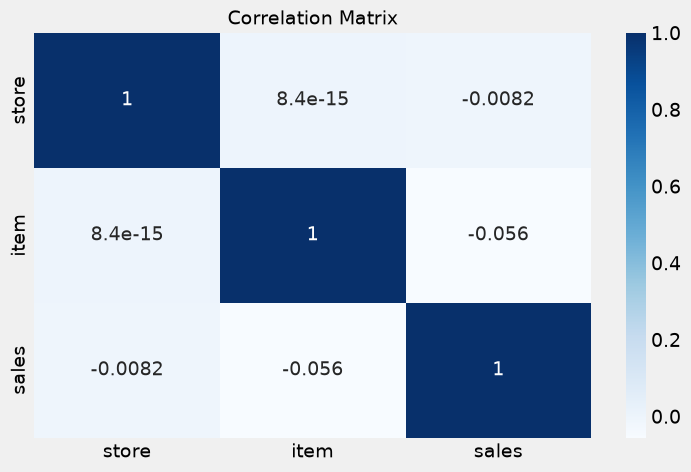

In [24]:
plt.figure(figsize=(8,5))

corr=df[['store','item','sales']].corr()

sns.heatmap(corr,annot=True,cmap='Blues')

plt.title("Correlation Matrix")

plt.show()

11. Time Series Plot

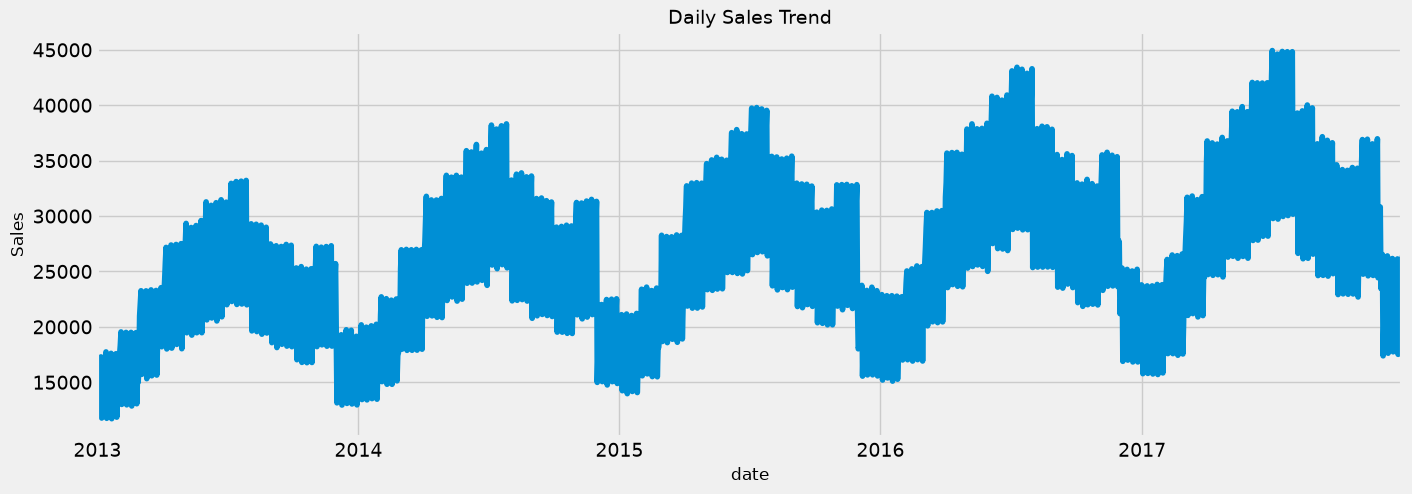

In [25]:
daily_sales=df.groupby('date')['sales'].sum()

plt.figure(figsize=(15,5))

daily_sales.plot()

plt.title("Daily Sales Trend")

plt.ylabel("Sales")

plt.show()

12. Boxplot (Outlier Detection)

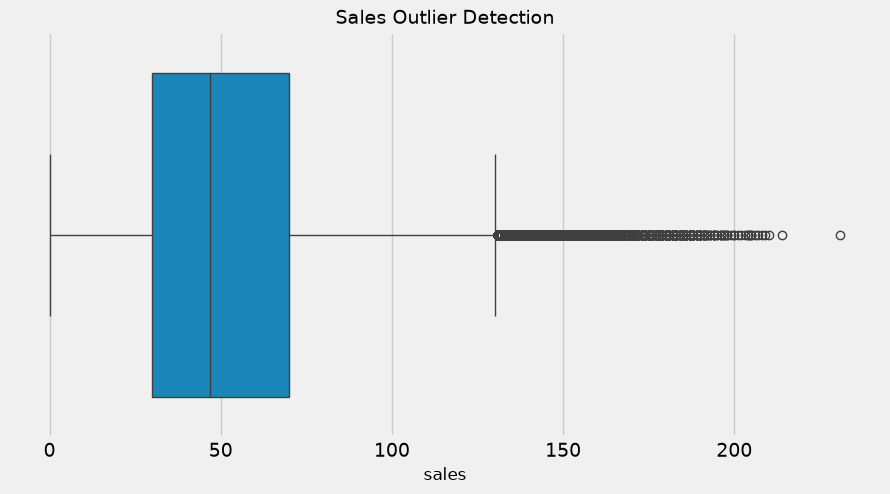

In [26]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['sales'])

plt.title("Sales Outlier Detection")

plt.show()

# 📈 Exploratory Data Analysis (EDA) Insights

The exploratory data analysis provides valuable insights into the structure, quality, and temporal characteristics of the retail demand dataset. The following observations summarize the key findings:

## 🔍 Data Quality

- ✅ The dataset contains **no missing values**, indicating high data completeness and reducing the need for imputation techniques.
- ✅ No significant duplicate records were detected after the validation process, ensuring data consistency and integrity.

---

## 📊 Sales Distribution

- Sales values exhibit a **positively skewed distribution**, where the majority of observations represent moderate demand while a small number of records correspond to exceptionally high sales.
- These high-demand observations behave as natural outliers commonly observed in retail datasets.

---

## 📅 Seasonal Trends

- Monthly sales analysis reveals **clear seasonal fluctuations**, indicating that customer demand changes over time.
- This confirms that temporal features such as month, day, and weekday are expected to improve forecasting performance.

---

## 🏪 Store-Level Analysis

- Sales vary noticeably across different stores.
- This suggests that each store possesses unique purchasing behavior and customer demand patterns, making store-specific modeling beneficial.

---

## 🛒 Item-Level Analysis

- A relatively small subset of products contributes a significant portion of overall sales.
- This indicates strong product-level demand concentration and highlights the importance of item-specific historical features.

---

## 📈 Time-Series Behavior

- Daily sales demonstrate recurring temporal patterns and consistent trends over time.
- These observations justify the use of lag features and rolling statistical windows for capturing historical demand dependencies.

---

## 🔗 Correlation Analysis

- Correlation analysis shows that **Store** and **Item** identifiers independently contribute to sales variation.
- The relationships support the development of a multi-series forecasting framework rather than treating the dataset as a single time series.

---

## 📦 Outlier Analysis

- Boxplot visualization identifies the presence of extreme sales values.
- These observations are expected in real-world retail environments and motivate the use of robust preprocessing and scaling techniques to minimize their impact.

---

## 🤖 Modeling Readiness

- The dataset demonstrates strong structural quality and temporal consistency, making it well-suited for advanced machine learning and deep learning algorithms.
- Feature engineering techniques such as lag variables, rolling averages, and calendar-based features are expected to substantially enhance predictive performance.

---

# ✅ Final Conclusion

Overall, the dataset provides a reliable and well-structured foundation for building a scalable **Multi-Series Retail Demand Forecasting** pipeline. Its high data quality, observable seasonal patterns, and meaningful temporal dependencies support the use of ensemble machine learning models (XGBoost and LightGBM) as well as deep learning approaches (LSTM) for accurate demand prediction.